# SpatioEv Manuscript — Figure Generation

This notebook generates all main-text figures (1–3) for the SpatioEv manuscript. It loads **pre-computed cached data** from the `data/` and `paper/notebooks/results/` directories, so no heavy recomputation is needed.

**Outputs:** `manuscript/figures/` (PDF + PNG at 300 dpi)

## Figure map
| Figure | Panels | Data source |
|--------|--------|-------------|
| Fig 1 | D–I: PCA, UMAP+tree, spatial map, module trends, branch heatmap, PanIN validation | `paper/notebooks/results/pseudotime_exp2/`, spatial cell tables |
| Fig 2 | A–C: Surround composition, fibroblast activation, interaction dynamics | `paper/notebooks/results/pseudotime_exp2/` |
| Fig 3 | A–H: Pooled UMAP, tree, boxplot, module trends, spatial maps, Xenium concordance | `data/combined_exp_2_3_4_5/`, `data/xenium_pancreas_10x/figures/` |

In [1]:
# ── Imports ───────────────────────────────────────────────────────────────────
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import seaborn as sns
from scipy import stats
import statsmodels.api as sm

# ── Publication-quality rcParams ──────────────────────────────────────────────
mpl.rcParams.update({
    'font.family': 'Arial',
    'font.size': 7,
    'axes.labelsize': 7,
    'axes.titlesize': 8,
    'xtick.labelsize': 6,
    'ytick.labelsize': 6,
    'legend.fontsize': 6,
    'axes.linewidth': 0.6,
    'xtick.major.width': 0.6,
    'ytick.major.width': 0.6,
    'xtick.major.size': 2.5,
    'ytick.major.size': 2.5,
    'lines.linewidth': 1.0,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'pdf.fonttype': 42,   # editable fonts in Illustrator
    'ps.fonttype': 42,
})

# ── Paths ─────────────────────────────────────────────────────────────────────
BASE = Path('/Users/shihongwu/SpatioEv')
RES_EXP2    = BASE / 'paper/notebooks/results/pseudotime_exp2'
COMB_DIR    = BASE / 'data/combined_exp_2_3_4_5'
XENIUM_FIG  = BASE / 'data/xenium_pancreas_10x/figures'
FIG_OUT     = BASE / 'manuscript/figures'
FIG_OUT.mkdir(parents=True, exist_ok=True)

def save_fig(fig, name, tight=True):
    for ext in ('pdf', 'png'):
        fig.savefig(FIG_OUT / f'{name}.{ext}', dpi=300, bbox_inches='tight' if tight else None)
    print(f'Saved: {FIG_OUT}/{name}.pdf/.png')

print('Paths OK. Output dir:', FIG_OUT)

Paths OK. Output dir: /Users/shihongwu/SpatioEv/manuscript/figures


In [2]:
# ── Shared colour palettes ────────────────────────────────────────────────────

# PDAC module colours (used throughout)
MODULE_PALETTE = {
    'pdac_early_duct_anchor_score':    '#2166AC',  # blue  — organised
    'pdac_panin_like_dysplasia_score': '#F4A582',  # salmon — dysplasia
    'pdac_invasive_gland_forming_score': '#D6604D', # orange-red — invasion
    'pdac_invasion_desmoplasia_score': '#B2182B',  # dark red — desmoplasia
    'pdac_proliferation_score':        '#762A83',  # purple — proliferation
    'pdac_dedifferentiation_score':    '#4DAC26',  # green — dedifferentiation
    'pdac_duct_organization_score':    '#2166AC',
    'pdac_dysplasia_score':            '#F4A582',
    'pdac_architectural_complexity_score': '#D6604D',
}
MODULE_LABELS = {
    'pdac_early_duct_anchor_score':      'Early-duct anchor',
    'pdac_panin_like_dysplasia_score':   'PanIN-like dysplasia',
    'pdac_invasive_gland_forming_score': 'Invasive gland-forming',
    'pdac_invasion_desmoplasia_score':   'Invasion–desmoplasia',
    'pdac_proliferation_score':          'Proliferation',
    'pdac_dedifferentiation_score':      'Dedifferentiation',
    'pdac_duct_organization_score':      'Duct organisation',
    'pdac_dysplasia_score':              'Dysplasia',
    'pdac_architectural_complexity_score': 'Architectural complexity',
}
SAMPLE_PALETTE = {
    '40331_1': '#4393C3',  # normal pancreas
    '33694_1': '#92C5DE',  # PDAC early
    '35559_1': '#F4A582',  # PDAC intermediate
    '34434_1': '#B2182B',  # PDAC invasive
}
DISEASE_PALETTE = {
    'Normal': '#4393C3',
    'PDAC': '#B2182B',
}
SAMPLE_LABELS = {
    '40331_1': 'Normal pancreas',
    '33694_1': 'PDAC (Grade I–II)',
    '35559_1': 'PDAC (Stage III)',
    '34434_1': 'PDAC (Grade 3)',
}

TIER_A_PALETTE = {
    'pancreatic ductal epithelium': '#2166AC',
    'pancreatic acinar epithelium': '#92C5DE',
    'Fibroblasts': '#F4A582',
    'T_cells': '#D6604D',
    'B_lineage': '#762A83',
    'Macrophages': '#4DAC26',
    'Endothelial_cells': '#E6AB02',
    'Neutrophils': '#A6761D',
    'Vimentin_only_mesenchyme': '#666666',
}

print('Palettes defined.')

Palettes defined.


---
# Figure 1 — Niche Construction and Single-Sample Pseudotime (IMC, sample 34434_1)

**Panels D–I** are generated here from pre-computed results.  
Panels A–C (conceptual schematic, spatial cell scatter, niche profile cards) are illustration/design elements; placeholder text is included.

In [3]:
# ── Load exp_2 data ───────────────────────────────────────────────────────────
df_pt     = pd.read_csv(RES_EXP2 / 'niche_pseudotime_results.csv')
df_mod    = pd.read_csv(RES_EXP2 / 'pathology_feature_table_with_modules.csv', low_memory=False)
df_pca_ev = pd.read_csv(RES_EXP2 / 'pca_explained_variance.csv')
df_branch = pd.read_csv(RES_EXP2 / 'branch_summary.csv')
df_trend  = pd.read_csv(RES_EXP2 / 'pdac_module_pseudotime_trends.csv')

# Merge pseudotime into module table
NICHE_KEY = 'pancreatic ductal epithelium_mask_component'
df_merged = df_mod.merge(
    df_pt[['pancreatic ductal epithelium_mask_component', 'image_id',
           'elpigraph_pseudotime', 'elpigraph_pseudotime_q',
           'principal_tree_branch', 'UMAP1', 'UMAP2']],
    on=['pancreatic ductal epithelium_mask_component', 'image_id'],
    how='inner',
)

MODULE_COLS_EXP2 = [
    'pdac_early_duct_anchor_score',
    'pdac_panin_like_dysplasia_score',
    'pdac_invasive_gland_forming_score',
    'pdac_invasion_desmoplasia_score',
    'pdac_proliferation_score',
]
MODULE_COLS_EXP2 = [c for c in MODULE_COLS_EXP2 if c in df_merged.columns]

# Load panin validation from combined (filter to exp_2)
df_panin_all = pd.read_pickle(COMB_DIR / 'pooled_pathology_with_panin_validation_scores.pkl')
df_panin = df_panin_all[df_panin_all['sample_id'] == '34434_1'].copy()

# FIX: pooled_pathology_with_panin_validation_scores has NO pseudotime columns.
# Merge pooled_pseudotime_q from pooled_niche_result_df for Fig 1I.
_NICHE_KEYS = ['pancreatic ductal epithelium_mask_component', 'image_id']
_df_pool_pt = pd.read_pickle(COMB_DIR / 'pooled_niche_result_df.pkl')
df_panin = df_panin.merge(
    _df_pool_pt[_NICHE_KEYS + ['pooled_pseudotime_q', 'major_branch']],
    on=_NICHE_KEYS, how='left'
)
df_panin_all = df_panin_all.merge(
    _df_pool_pt[_NICHE_KEYS + ['pooled_pseudotime_q', 'major_branch', 'UMAP1', 'UMAP2']],
    on=_NICHE_KEYS, how='left'
)

# Load spatial cells for exp_2
df_spatial = pd.read_pickle(COMB_DIR / 'spatial_cells_auto_branch_n36_v5_contextual_34434_1.pkl')

print(f'Merged niches: {len(df_merged)}')
print(f'PanIN validation rows: {len(df_panin)}')
print(f'Spatial cells: {len(df_spatial)}')

Merged niches: 12184
PanIN validation rows: 12184
Spatial cells: 1763634


Saved: /Users/shihongwu/SpatioEv/manuscript/figures/fig1D_pca_scree_and_module_pca.pdf/.png


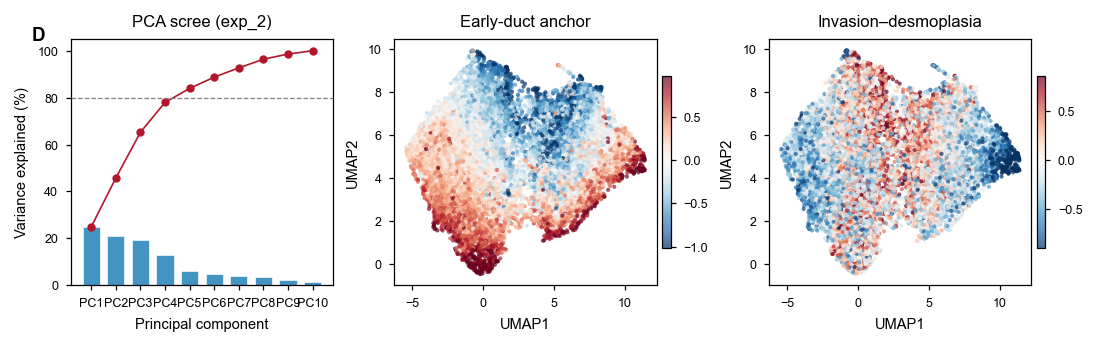

In [4]:
# ── Fig 1D — PCA scree + 2D PCA coloured by early-duct-anchor score ─────────
def lowess_smooth(x, y, frac=0.25):
    """Return smoothed y values from LOWESS."""
    xy = np.column_stack([x, y])
    xy = xy[~np.isnan(xy).any(axis=1)]
    xy = xy[np.argsort(xy[:, 0])]
    smoothed = sm.nonparametric.lowess(xy[:, 1], xy[:, 0], frac=frac)
    return smoothed[:, 0], smoothed[:, 1]

fig, axes = plt.subplots(1, 3, figsize=(7.2, 2.2), constrained_layout=True)

# Panel 1: Scree plot
ax = axes[0]
n_show = min(10, len(df_pca_ev))
ax.bar(df_pca_ev['PC'][:n_show],
       df_pca_ev['explained_variance_ratio'][:n_show] * 100,
       color='#4393C3', edgecolor='white', linewidth=0.3, width=0.7)
ax.plot(df_pca_ev['PC'][:n_show],
        df_pca_ev['cumulative_variance_ratio'][:n_show] * 100,
        'o-', color='#B2182B', markersize=3, linewidth=0.8)
ax.axhline(80, color='gray', linestyle='--', linewidth=0.6)
ax.set_xlabel('Principal component')
ax.set_ylabel('Variance explained (%)')
ax.set_title('PCA scree (exp_2)')
ax.set_xticks(df_pca_ev['PC'][:n_show])

# Panels 2 & 3: 2D PCA coloured by two opposing modules
pca_cols = ['PC1', 'PC2']
if all(c in df_merged.columns for c in pca_cols):
    for ax, mod_col in zip(axes[1:3], ['pdac_early_duct_anchor_score', 'pdac_invasion_desmoplasia_score']):
        if mod_col not in df_merged.columns:
            ax.set_visible(False)
            continue
        v = df_merged[mod_col]
        vmin, vmax = v.quantile(0.02), v.quantile(0.98)
        sc = ax.scatter(df_merged['PC1'], df_merged['PC2'],
                        c=v.clip(vmin, vmax),
                        cmap='RdBu_r', s=4, linewidths=0, alpha=0.7,
                        vmin=vmin, vmax=vmax, rasterized=True)
        plt.colorbar(sc, ax=ax, shrink=0.7, pad=0.02)
        ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
        ax.set_title(MODULE_LABELS.get(mod_col, mod_col))
        ax.set_aspect('equal', adjustable='datalim')
else:
    # Fall back to UMAP
    for ax, mod_col in zip(axes[1:3], ['pdac_early_duct_anchor_score', 'pdac_invasion_desmoplasia_score']):
        if mod_col not in df_merged.columns:
            ax.set_visible(False); continue
        v = df_merged[mod_col]
        vmin, vmax = v.quantile(0.02), v.quantile(0.98)
        sc = ax.scatter(df_merged['UMAP1'], df_merged['UMAP2'],
                        c=v.clip(vmin, vmax), cmap='RdBu_r', s=4, linewidths=0,
                        alpha=0.7, vmin=vmin, vmax=vmax, rasterized=True)
        plt.colorbar(sc, ax=ax, shrink=0.7, pad=0.02)
        ax.set_xlabel('UMAP1'); ax.set_ylabel('UMAP2')
        ax.set_title(MODULE_LABELS.get(mod_col, mod_col))

# All 3 sub-panels belong to panel D — label only the first axis
axes[0].text(-0.15, 1.05, 'D', transform=axes[0].transAxes,
             fontsize=9, fontweight='bold', va='top')

save_fig(fig, 'fig1D_pca_scree_and_module_pca')
plt.show()

Saved: /Users/shihongwu/SpatioEv/manuscript/figures/fig1E_umap_branch_pseudotime.pdf/.png


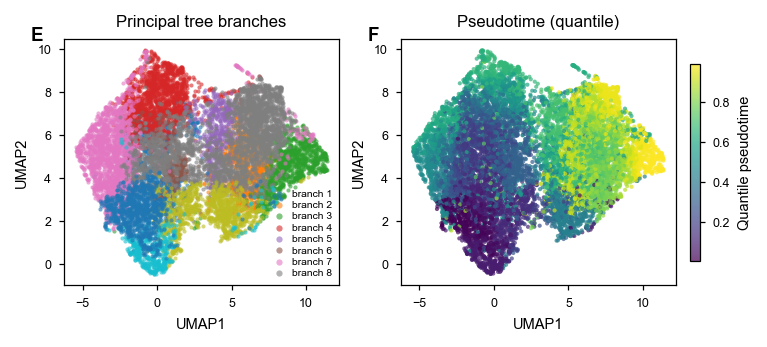

In [5]:
# ── Fig 1E — UMAP coloured by branch and pseudotime ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(5.0, 2.2), constrained_layout=True)

# Build branch palette from actual labels
branches = sorted(df_merged['principal_tree_branch'].dropna().unique())
branch_colors = sns.color_palette('tab10', len(branches))
branch_pal = dict(zip(branches, branch_colors))

# UMAP coloured by branch
ax = axes[0]
for branch, grp in df_merged.groupby('principal_tree_branch'):
    ax.scatter(grp['UMAP1'], grp['UMAP2'],
               c=[branch_pal.get(branch, '#cccccc')],
               s=4, linewidths=0, alpha=0.6, rasterized=True,
               label=branch)
ax.set_xlabel('UMAP1'); ax.set_ylabel('UMAP2')
ax.set_title('Principal tree branches')
# Compact legend (at most 8 entries)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:8], labels[:8], markerscale=1.5, frameon=False,
          handlelength=0.8, borderpad=0.2, labelspacing=0.2, fontsize=5)

# UMAP coloured by pseudotime
ax = axes[1]
sc = ax.scatter(df_merged['UMAP1'], df_merged['UMAP2'],
                c=df_merged['elpigraph_pseudotime_q'],
                cmap='viridis', s=4, linewidths=0, alpha=0.7, rasterized=True)
plt.colorbar(sc, ax=ax, shrink=0.8, label='Quantile pseudotime')
ax.set_xlabel('UMAP1'); ax.set_ylabel('UMAP2')
ax.set_title('Pseudotime (quantile)')

for i, ax in enumerate(axes):
    ax.text(-0.12, 1.05, 'EF'[i], transform=ax.transAxes,
            fontsize=9, fontweight='bold', va='top')

save_fig(fig, 'fig1E_umap_branch_pseudotime')
plt.show()

Saved: /Users/shihongwu/SpatioEv/manuscript/figures/fig1F_spatial_pseudotime_exp2.pdf/.png


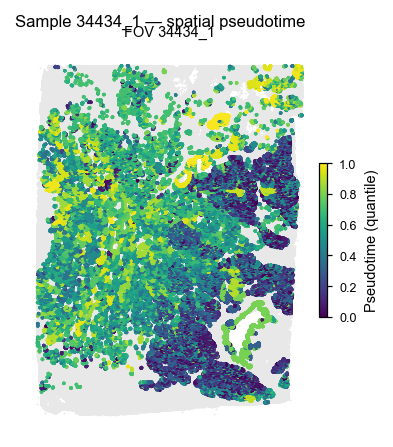

In [6]:
# ── Fig 1F — Spatial map of pseudotime in exp_2 ───────────────────────────────
# Use ductal cells only (cells that belong to a niche)
df_duct = df_spatial[df_spatial['has_pooled_niche'] == True].copy()
df_nonductal = df_spatial[df_spatial['has_pooled_niche'] == False].copy()

# Filter to exp_2 sample only
df_duct = df_duct[df_duct['sample_id'] == '34434_1']
df_nonductal = df_nonductal[df_nonductal['sample_id'] == '34434_1'] if 'sample_id' in df_nonductal.columns else df_nonductal

# Get image IDs
images = sorted(df_duct['image_id'].unique())
n_img = len(images)
ncols = min(3, n_img)
nrows = (n_img + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.0, nrows * 2.8),
                          constrained_layout=True)
axes = np.array(axes).reshape(-1) if n_img > 1 else [axes]

norm = Normalize(vmin=0, vmax=1)
cmap = plt.cm.viridis

for ax, img_id in zip(axes, images):
    nd = df_nonductal[df_nonductal['image_id'] == img_id] if 'image_id' in df_nonductal.columns else pd.DataFrame()
    d  = df_duct[df_duct['image_id'] == img_id]
        # FIX: spatial cells have pooled_pseudotime (0-22), not pooled_pseudotime_q.
    # Rank-based quantile normalisation to [0,1] inline.
    pt_raw_col = 'pooled_pseudotime' if 'pooled_pseudotime' in d.columns else 'simple_pseudotime'
    if pt_raw_col not in d.columns:
        ax.set_visible(False); continue

    # Background: non-ductal cells in grey
    if len(nd) > 0:
        ax.scatter(nd['x'], nd['y'], c='#e8e8e8', s=0.8, linewidths=0,
                   rasterized=True, zorder=1)
    # Quantile-normalise pseudotime to [0,1] for consistent colour scale across FOVs
    pt_raw = pd.to_numeric(d[pt_raw_col], errors='coerce')
    pt_vals = pt_raw.rank(pct=True)   # pandas rank(pct=True) → (0,1]
    sc = ax.scatter(d['x'], d['y'],
                    c=pt_vals.clip(0, 1),
                    cmap='viridis', s=2.5, linewidths=0,
                    vmin=0, vmax=1, rasterized=True, zorder=2)
    ax.set_aspect('equal')
    ax.set_title(f'FOV {img_id}', fontsize=7)
    ax.axis('off')

for ax in axes[n_img:]:
    ax.set_visible(False)

# Shared colorbar
sm = ScalarMappable(cmap='viridis', norm=Normalize(0, 1))
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes[:n_img], shrink=0.4, label='Pseudotime (quantile)', pad=0.01)

fig.suptitle('Sample 34434_1 — spatial pseudotime', fontsize=8, y=1.01)
save_fig(fig, 'fig1F_spatial_pseudotime_exp2')
plt.show()

Saved: /Users/shihongwu/SpatioEv/manuscript/figures/fig1G_module_lowess_trends_exp2.pdf/.png


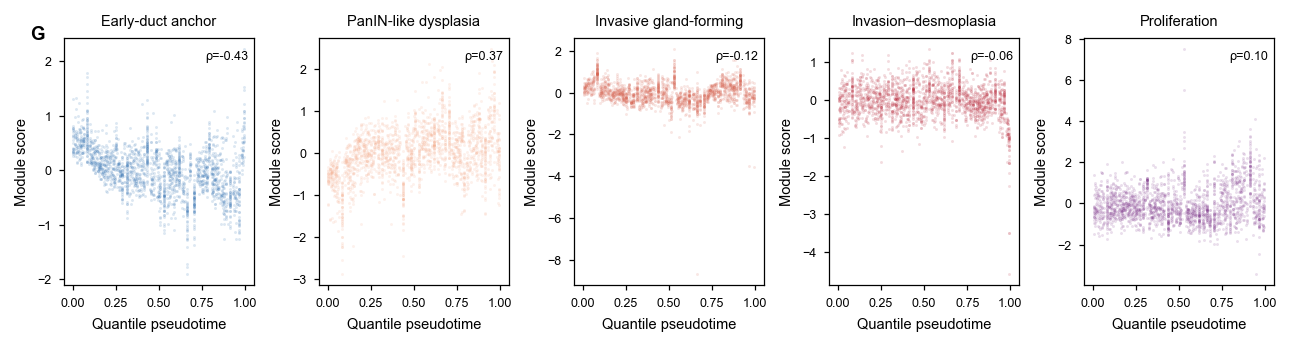

In [7]:
# ── Fig 1G — LOWESS module trends along pseudotime ───────────────────────────
# For each module, plot scatter + LOWESS smooth coloured by module colour

pt_col = 'elpigraph_pseudotime_q'
mod_plot = [c for c in MODULE_COLS_EXP2 if c in df_merged.columns][:5]

fig, axes = plt.subplots(1, len(mod_plot), figsize=(len(mod_plot) * 1.7, 2.2),
                          constrained_layout=True)

for ax, col in zip(axes, mod_plot):
    vals = pd.to_numeric(df_merged[col], errors='coerce')
    pt   = pd.to_numeric(df_merged[pt_col], errors='coerce')
    mask = ~(np.isnan(vals) | np.isnan(pt))
    color = MODULE_PALETTE.get(col, '#555555')

    # Scatter (downsample for speed)
    idx = np.random.choice(np.where(mask)[0], size=min(2000, mask.sum()), replace=False)
    ax.scatter(pt.values[idx], vals.values[idx],
               c=color, s=2, alpha=0.15, linewidths=0, rasterized=True)

    # LOWESS
    try:
        lx, ly = lowess_smooth(pt.values[mask], vals.values[mask], frac=0.25)
        ax.plot(lx, ly, color=color, linewidth=1.5)
    except Exception:
        pass

    # Spearman r annotation
    r, p = stats.spearmanr(pt.values[mask], vals.values[mask])
    ax.text(0.97, 0.95, f'ρ={r:.2f}', transform=ax.transAxes,
            ha='right', va='top', fontsize=6,
            color='black' if p < 0.05 else 'gray')

    ax.set_xlabel('Quantile pseudotime')
    ax.set_ylabel('Module score')
    ax.set_title(MODULE_LABELS.get(col, col), fontsize=7)
    ax.set_xlim(-0.05, 1.05)

axes[0].text(-0.18, 1.05, 'G', transform=axes[0].transAxes,
             fontsize=9, fontweight='bold', va='top')

save_fig(fig, 'fig1G_module_lowess_trends_exp2')
plt.show()

Saved: /Users/shihongwu/SpatioEv/manuscript/figures/fig1H_branch_module_heatmap_exp2.pdf/.png


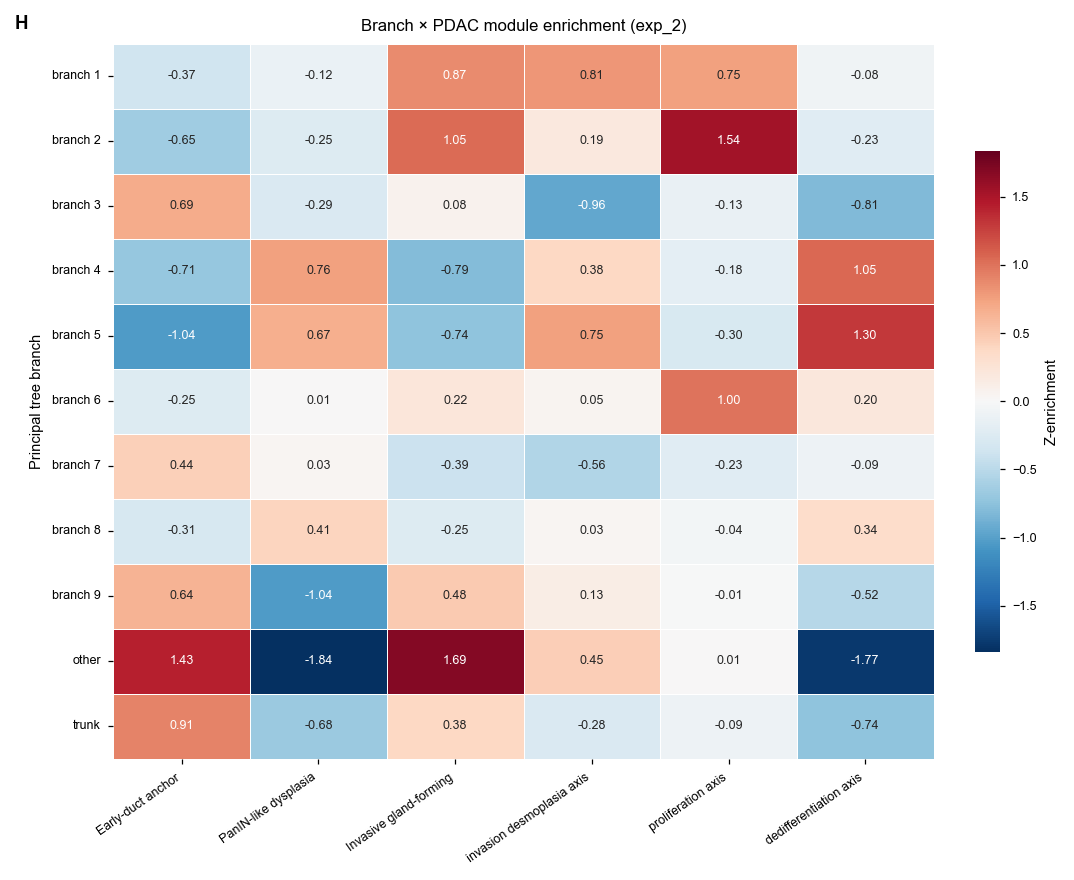

In [8]:
# ── Fig 1H — Branch × PDAC module z-enrichment heatmap ──────────────────────

z_cols = [c for c in df_branch.columns if c.endswith('__z_enrichment')]
z_labels = {
    c: MODULE_LABELS.get(c.replace('__z_enrichment', ''), c.replace('__z_enrichment', '').replace('pdac_', '').replace('_', ' '))
    for c in z_cols
}

if z_cols and len(df_branch) > 0:
    heatmap_df = df_branch.set_index('branch')[z_cols].rename(columns=z_labels)

    fig, ax = plt.subplots(figsize=(len(z_cols) * 1.1 + 0.5, len(df_branch) * 0.45 + 0.8),
                            constrained_layout=True)
    vmax = max(abs(heatmap_df.values.max()), abs(heatmap_df.values.min()), 1)
    sns.heatmap(
        heatmap_df,
        cmap='RdBu_r', center=0, vmin=-vmax, vmax=vmax,
        annot=True, fmt='.2f', annot_kws={'size': 6},
        linewidths=0.4, linecolor='white',
        cbar_kws={'shrink': 0.7, 'label': 'Z-enrichment'},
        ax=ax,
    )
    ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right', fontsize=6)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=6)
    ax.set_ylabel('Principal tree branch')
    ax.set_title('Branch × PDAC module enrichment (exp_2)')
    ax.text(-0.12, 1.04, 'H', transform=ax.transAxes,
            fontsize=9, fontweight='bold', va='top')

    save_fig(fig, 'fig1H_branch_module_heatmap_exp2')
    plt.show()
else:
    print('No z-enrichment columns found in branch summary — check branch_summary.csv')

Saved: /Users/shihongwu/SpatioEv/manuscript/figures/fig1I_panin_validation_exp2.pdf/.png


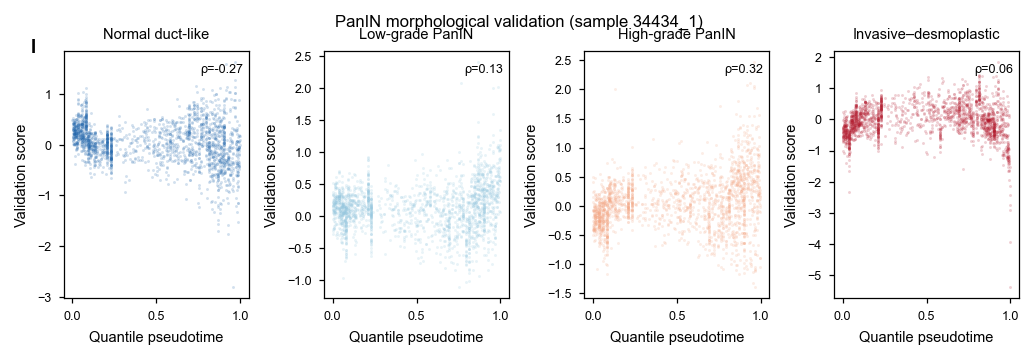

In [9]:
# ── Fig 1I — PanIN validation scores along pseudotime ────────────────────────
PANIN_COLS = [
    'panin_validation__normal_duct_like_score',
    'panin_validation__lg_panin_like_score',
    'panin_validation__hg_panin_like_score',
    'panin_validation__invasive_desmoplastic_context_score',
]
PANIN_LABELS = {
    'panin_validation__normal_duct_like_score':            'Normal duct-like',
    'panin_validation__lg_panin_like_score':               'Low-grade PanIN',
    'panin_validation__hg_panin_like_score':               'High-grade PanIN',
    'panin_validation__invasive_desmoplastic_context_score': 'Invasive–desmoplastic',
}
PANIN_COLORS = ['#2166AC', '#92C5DE', '#F4A582', '#B2182B']

panin_plot_cols = [c for c in PANIN_COLS if c in df_panin.columns]
pt_col_p = 'pooled_pseudotime_q'  # added by Fix 1 merge above

if panin_plot_cols and pt_col_p in df_panin.columns:
    fig, axes = plt.subplots(1, len(panin_plot_cols),
                              figsize=(len(panin_plot_cols) * 1.7, 2.2),
                              constrained_layout=True)

    for ax, col, color in zip(axes, panin_plot_cols, PANIN_COLORS):
        vals = pd.to_numeric(df_panin[col], errors='coerce')
        pt   = pd.to_numeric(df_panin[pt_col_p], errors='coerce')
        mask = ~(np.isnan(vals) | np.isnan(pt))

        idx = np.random.choice(np.where(mask)[0], size=min(2000, mask.sum()), replace=False)
        ax.scatter(pt.values[idx], vals.values[idx],
                   c=color, s=2, alpha=0.2, linewidths=0, rasterized=True)

        try:
            lx, ly = lowess_smooth(pt.values[mask], vals.values[mask], frac=0.3)
            ax.plot(lx, ly, color=color, linewidth=1.8)
        except Exception:
            pass

        r, p = stats.spearmanr(pt.values[mask], vals.values[mask])
        ax.text(0.97, 0.95, f'ρ={r:.2f}', transform=ax.transAxes,
                ha='right', va='top', fontsize=6)
        ax.set_xlabel('Quantile pseudotime')
        ax.set_ylabel('Validation score')
        ax.set_title(PANIN_LABELS.get(col, col), fontsize=7)
        ax.set_xlim(-0.05, 1.05)

    axes[0].text(-0.18, 1.05, 'I', transform=axes[0].transAxes,
                 fontsize=9, fontweight='bold', va='top')
    fig.suptitle('PanIN morphological validation (sample 34434_1)', fontsize=8, y=1.02)

    save_fig(fig, 'fig1I_panin_validation_exp2')
    plt.show()
else:
    print('PanIN validation columns not available for exp_2 subset. Available cols:', panin_plot_cols)

Saved: /Users/shihongwu/SpatioEv/manuscript/figures/Figure1_manuscript_DtoI.pdf/.png


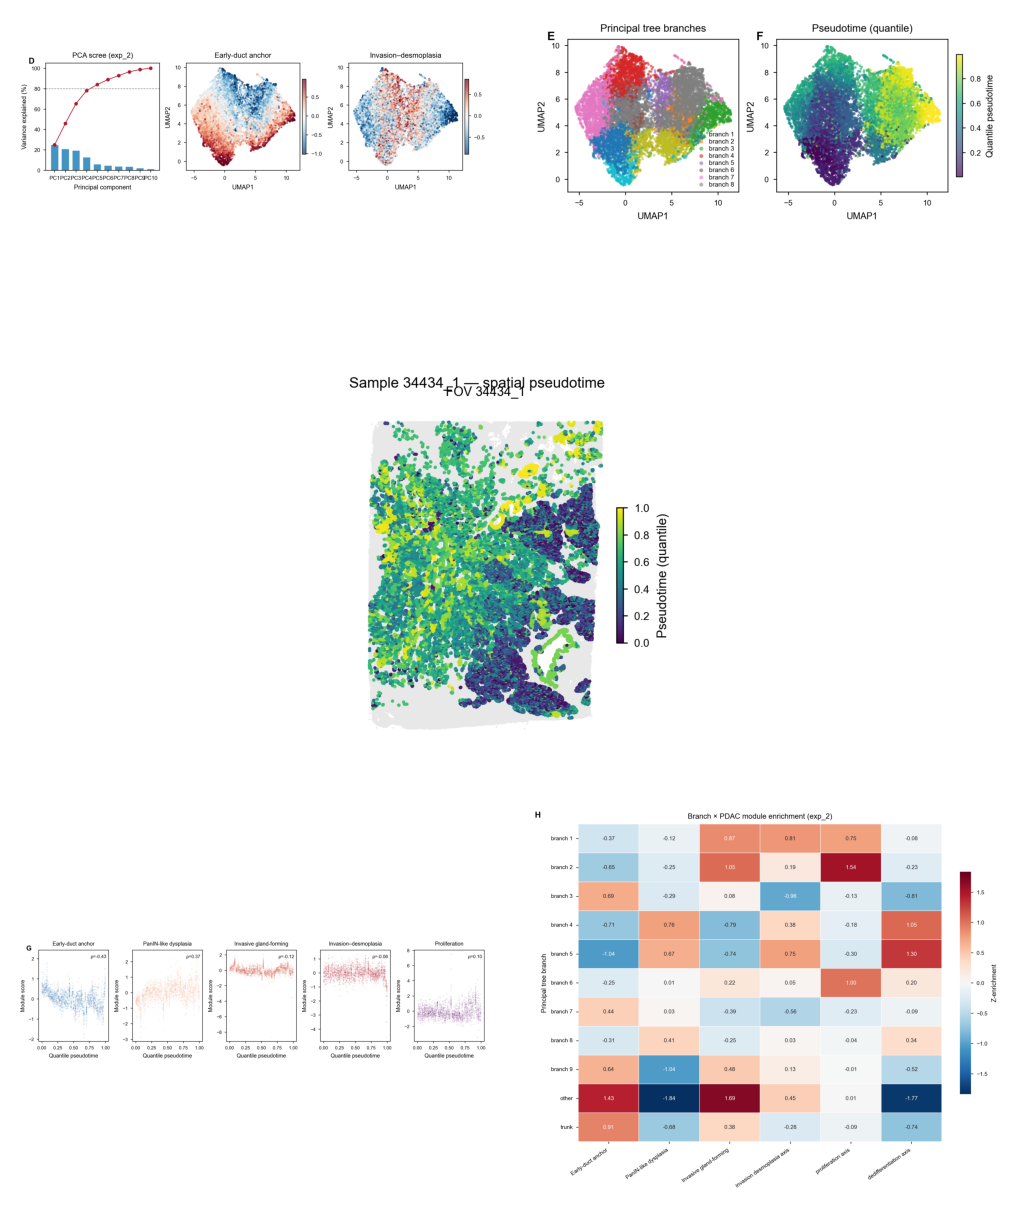

Figure 1 (panels D-I) assembled.


In [10]:
# ── Fig 1 composite — assemble D-I into a single figure ──────────────────────
# Load saved panels and assemble with gridspec
import matplotlib.image as mpimg

panel_files = {
    'D': FIG_OUT / 'fig1D_pca_scree_and_module_pca.png',
    'E': FIG_OUT / 'fig1E_umap_branch_pseudotime.png',
    'F': FIG_OUT / 'fig1F_spatial_pseudotime_exp2.png',
    'G': FIG_OUT / 'fig1G_module_lowess_trends_exp2.png',
    'H': FIG_OUT / 'fig1H_branch_module_heatmap_exp2.png',
    'I': FIG_OUT / 'fig1I_panin_validation_exp2.png',
}

fig = plt.figure(figsize=(8.5, 11), dpi=150)
gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.12, wspace=0.08)

layout = [('D', gs[0, 0]), ('E', gs[0, 1]),
          ('F', gs[1, :]),
          ('G', gs[2, 0]), ('H+I', gs[2, 1])]

for label, pos in [('D', (0,0)), ('E', (0,1))]:
    pfile = panel_files.get(label)
    if pfile and pfile.exists():
        ax = fig.add_subplot(gs[pos[0], pos[1]])
        ax.imshow(mpimg.imread(pfile))
        ax.axis('off')

# Row 1: spatial map (full width)
pfile = panel_files.get('F')
if pfile and pfile.exists():
    ax = fig.add_subplot(gs[1, :])
    ax.imshow(mpimg.imread(pfile))
    ax.axis('off')

# Row 2: module trends and branch heatmap
for label, col in [('G', 0), ('H', 1)]:
    pfile = panel_files.get(label)
    if pfile and pfile.exists():
        ax = fig.add_subplot(gs[2, col])
        ax.imshow(mpimg.imread(pfile))
        ax.axis('off')

save_fig(fig, 'Figure1_manuscript_DtoI')
plt.show()
print('Figure 1 (panels D-I) assembled.')

---
# Figure 2 — Microenvironment Dynamics Along the Single-Sample Trajectory


In [11]:
# ── Load Figure 2 data ────────────────────────────────────────────────────────
df_surround = pd.read_csv(RES_EXP2 / 'surrounding_context_pseudotime_trends.csv')
df_interact = pd.read_csv(RES_EXP2 / 'tier_a_interaction_bins.csv')
df_interact_br = pd.read_csv(RES_EXP2 / 'tier_a_branch_stratified_interaction_bins.csv')

# Also load merged data for computing the actual LOWESS trends
# (the surround CSV has Spearman stats only; we need the raw feature values)
surround_prop_features = [f for f in df_surround['feature'].unique() if f.startswith('surround_prop__')]
fibro_marker_features  = [f for f in df_surround['feature'].unique() if 'Fibroblasts__' in f and 'expr' in f]
print('Surround proportions:', surround_prop_features)
print('Fibroblast markers:', fibro_marker_features)

Surround proportions: ['surround_prop__Fibroblasts', 'surround_prop__B_lineage', 'surround_prop__T_cells', 'surround_prop__Vimentin_only_mesenchyme', 'surround_prop__Endothelial_cells', 'surround_prop__pancreatic_ductal_epithelium', 'surround_prop__pancreatic_acinar_epithelium']
Fibroblast markers: ['surround__Fibroblasts__PDPN_expr__mean', 'surround__Fibroblasts__FAP_expr__mean', 'surround__Fibroblasts__aSMA_expr__mean', 'surround__Fibroblasts__Thy1_expr__mean', 'surround__Fibroblasts__Vimentin_expr__mean']


Saved: /Users/shihongwu/SpatioEv/manuscript/figures/fig2A_surround_cell_proportion_trends.pdf/.png


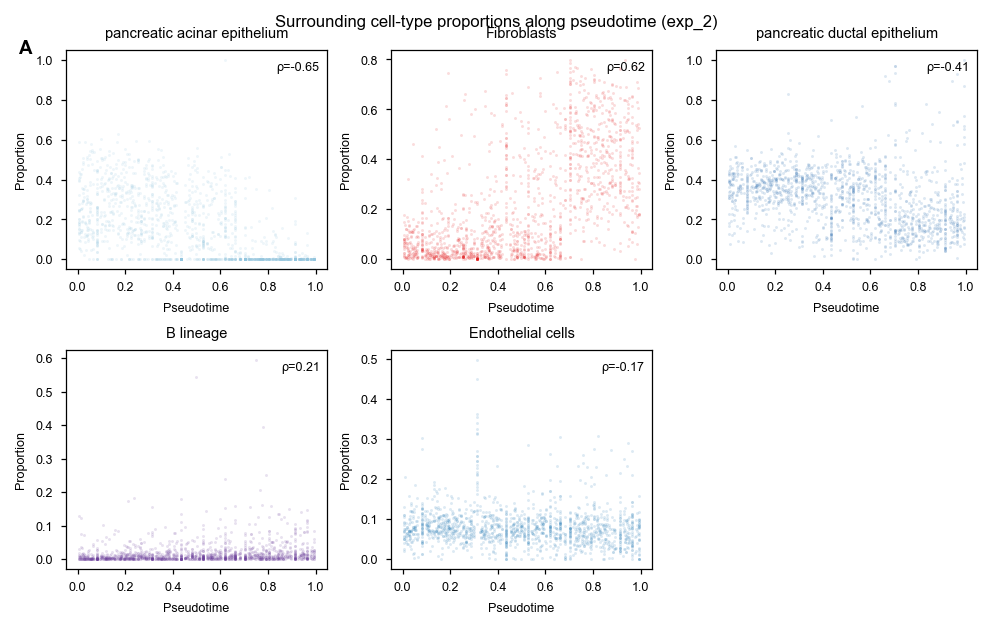

In [12]:
# ── Fig 2A — Surrounding cell-type proportions along pseudotime ───────────────
# Load the raw merged data (module features + pseudotime) for LOWESS

# Load FULL feature table (includes surround columns)
df_mod_full = pd.read_csv(RES_EXP2 / 'pathology_feature_table_with_modules.csv', low_memory=False)
df_merged_full = df_mod_full.merge(
    df_pt[['pancreatic ductal epithelium_mask_component', 'image_id',
           'elpigraph_pseudotime_q', 'principal_tree_branch']],
    on=['pancreatic ductal epithelium_mask_component', 'image_id'], how='inner'
)

# FIX: Use the surround_context_pseudotime_trends.csv to select the most
# informative proportion features (ranked by |Spearman r|), excluding
# spurious anatomical cell types that only appear in a minority of FOVs.
_surr_stats = pd.read_csv(RES_EXP2 / 'surrounding_context_pseudotime_trends.csv')
_prop_stats  = _surr_stats[_surr_stats['feature'].str.startswith('surround_prop__')].copy()
_prop_stats['abs_r'] = _prop_stats['spearman_r'].abs()
_prop_stats = _prop_stats.sort_values('abs_r', ascending=False)

# Keep only features present in the feature table and with |r| > 0.1
_valid_prop = [f for f in _prop_stats['feature'] if f in df_merged_full.columns
               and _prop_stats.loc[_prop_stats['feature']==f, 'abs_r'].values[0] > 0.1]
prop_cols = _valid_prop[:6]

CELL_TYPE_PALETTE = {
    'Fibroblasts':                  '#E31A1C',
    'T_cells':                      '#FF7F00',
    'B_lineage':                    '#6A3D9A',
    'Endothelial_cells':            '#1F78B4',
    'Vimentin_only_mesenchyme':     '#B15928',
    'Macrophages':                  '#33A02C',
    'Neutrophils':                  '#A6CEE3',
    'pancreatic_ductal_epithelium': '#2166AC',
    'pancreatic_acinar_epithelium': '#92C5DE',
}

def cell_type_from_col(col):
    return col.replace('surround_prop__', '').replace('_', ' ')

if prop_cols and 'elpigraph_pseudotime_q' in df_merged_full.columns:
    pt_col = 'elpigraph_pseudotime_q'
    fig, axes = plt.subplots(2, 3, figsize=(6.5, 4.0), constrained_layout=True)
    axes = axes.reshape(-1)

    for ax, col in zip(axes, prop_cols):
        cell_type = cell_type_from_col(col)
        color = CELL_TYPE_PALETTE.get(col.replace('surround_prop__', ''), '#666666')
        vals = pd.to_numeric(df_merged_full[col], errors='coerce')
        pt   = pd.to_numeric(df_merged_full[pt_col], errors='coerce')
        mask = ~(np.isnan(vals) | np.isnan(pt))

        idx = np.random.choice(np.where(mask)[0], size=min(1500, mask.sum()), replace=False)
        ax.scatter(pt.values[idx], vals.values[idx],
                   c=color, s=2, alpha=0.15, linewidths=0, rasterized=True)
        try:
            lx, ly = lowess_smooth(pt.values[mask], vals.values[mask], frac=0.25)
            ax.plot(lx, ly, color=color, linewidth=1.5)
        except Exception:
            pass

        r, _ = stats.spearmanr(pt.values[mask], vals.values[mask])
        ax.text(0.97, 0.95, f'ρ={r:.2f}', transform=ax.transAxes,
                ha='right', va='top', fontsize=6)
        ax.set_title(cell_type.replace('_', ' '), fontsize=7)
        ax.set_xlabel('Pseudotime', fontsize=6)
        ax.set_ylabel('Proportion', fontsize=6)
        ax.set_xlim(-0.05, 1.05)

    for ax in axes[len(prop_cols):]:
        ax.set_visible(False)

    axes[0].text(-0.18, 1.05, 'A', transform=axes[0].transAxes,
                 fontsize=9, fontweight='bold', va='top')
    fig.suptitle('Surrounding cell-type proportions along pseudotime (exp_2)', fontsize=8, y=1.01)

    save_fig(fig, 'fig2A_surround_cell_proportion_trends')
    plt.show()
else:
    print('Surround proportion columns not found in feature table.')
    print('Available surround cols (first 10):', surround_feature_cols[:10])

Saved: /Users/shihongwu/SpatioEv/manuscript/figures/fig2B_fibroblast_activation_trends.pdf/.png


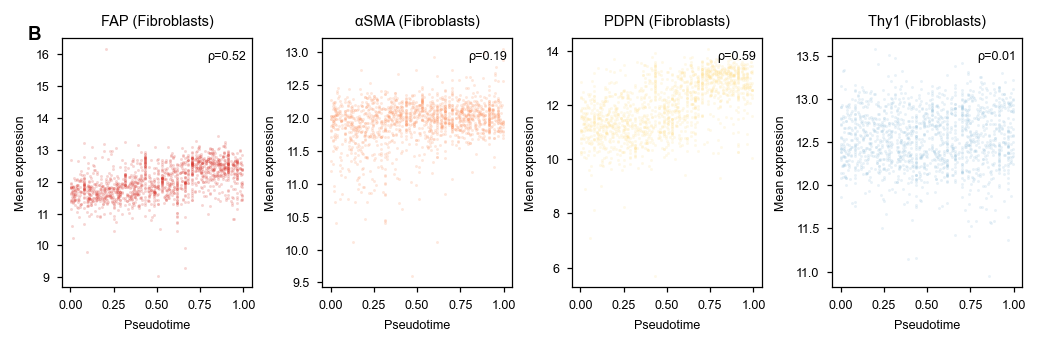

In [13]:
# ── Fig 2B — Fibroblast activation markers along pseudotime ───────────────────
FIBRO_MARKER_COLS = [
    'surround__Fibroblasts__FAP_expr__mean',
    'surround__Fibroblasts__aSMA_expr__mean',
    'surround__Fibroblasts__PDPN_expr__mean',
    'surround__Fibroblasts__Thy1_expr__mean',
]
FIBRO_LABELS = {
    'surround__Fibroblasts__FAP_expr__mean':  'FAP (Fibroblasts)',
    'surround__Fibroblasts__aSMA_expr__mean': 'αSMA (Fibroblasts)',
    'surround__Fibroblasts__PDPN_expr__mean': 'PDPN (Fibroblasts)',
    'surround__Fibroblasts__Thy1_expr__mean': 'Thy1 (Fibroblasts)',
}
CAF_COLORS = ['#D73027', '#FC8D59', '#FEE090', '#91BFDB']

fibro_plot_cols = [c for c in FIBRO_MARKER_COLS if c in df_merged_full.columns]

if fibro_plot_cols:
    fig, axes = plt.subplots(1, len(fibro_plot_cols),
                              figsize=(len(fibro_plot_cols) * 1.7, 2.2),
                              constrained_layout=True)

    for ax, col, color in zip(axes, fibro_plot_cols, CAF_COLORS):
        vals = pd.to_numeric(df_merged_full[col], errors='coerce')
        pt   = pd.to_numeric(df_merged_full[pt_col], errors='coerce')
        mask = ~(np.isnan(vals) | np.isnan(pt))

        idx = np.random.choice(np.where(mask)[0], size=min(1500, mask.sum()), replace=False)
        ax.scatter(pt.values[idx], vals.values[idx],
                   c=color, s=2, alpha=0.2, linewidths=0, rasterized=True)
        try:
            lx, ly = lowess_smooth(pt.values[mask], vals.values[mask], frac=0.28)
            ax.plot(lx, ly, color=color, linewidth=1.5)
        except Exception:
            pass

        r, _ = stats.spearmanr(pt.values[mask], vals.values[mask])
        ax.text(0.97, 0.95, f'ρ={r:.2f}', transform=ax.transAxes,
                ha='right', va='top', fontsize=6)
        ax.set_title(FIBRO_LABELS.get(col, col), fontsize=7)
        ax.set_xlabel('Pseudotime', fontsize=6)
        ax.set_ylabel('Mean expression', fontsize=6)
        ax.set_xlim(-0.05, 1.05)

    axes[0].text(-0.18, 1.05, 'B', transform=axes[0].transAxes,
                 fontsize=9, fontweight='bold', va='top')

    save_fig(fig, 'fig2B_fibroblast_activation_trends')
    plt.show()
else:
    print('Fibroblast marker columns not found. Columns starting with surround__Fibroblasts:')
    fib_cols = [c for c in df_merged_full.columns if 'Fibroblasts' in c and 'expr' in c]
    print(fib_cols[:10])

Saved: /Users/shihongwu/SpatioEv/manuscript/figures/fig2C_interaction_dynamics_heatmap.pdf/.png


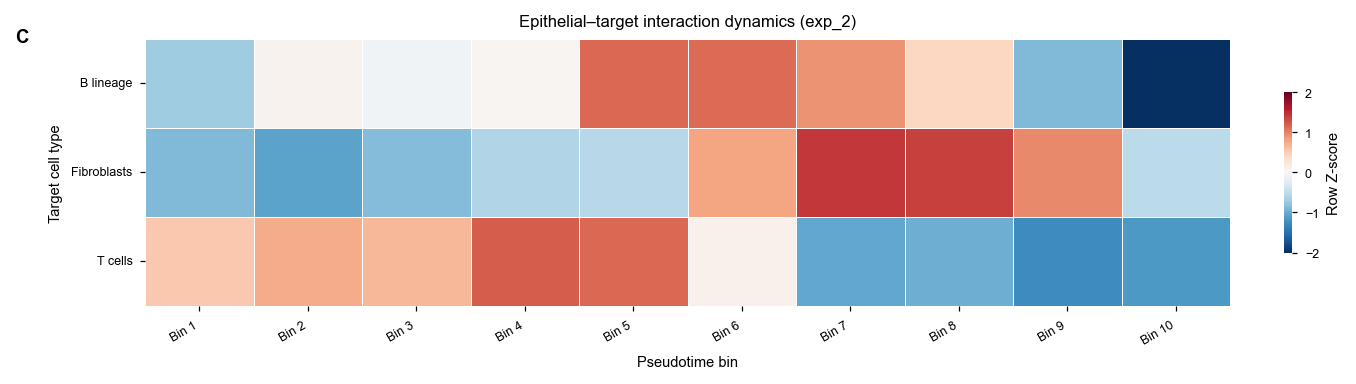

In [14]:
# ── Fig 2C — Epithelial-centred interaction dynamics heatmap ─────────────────
# tier_a_interaction_bins: rows = (target_phenotype × pseudotime_bin)
# Pivot to: rows = target phenotype, columns = pseudotime bin

pivot_col = 'fraction_source_with_target_neighbor'  # or 'mean_target_neighbor_count'

df_interact_filt = df_interact.copy()

# Exclude self-interactions and non-informative types
exclude = ['pancreatic ductal epithelium', 'pancreatic acinar epithelium']
df_interact_filt = df_interact_filt[
    ~df_interact_filt['target_phenotype'].isin(exclude)
]

pivot = df_interact_filt.pivot_table(
    index='target_phenotype',
    columns='pseudotime_bin',
    values=pivot_col,
    aggfunc='mean',
)

# Z-score each row so we see relative change along trajectory
pivot_z = pivot.subtract(pivot.mean(axis=1), axis=0).divide(pivot.std(axis=1) + 1e-6, axis=0)
pivot_z.index = pivot_z.index.str.replace('_', ' ')
pivot_z.columns = [f'Bin {c+1}' for c in pivot_z.columns]

fig, ax = plt.subplots(figsize=(pivot_z.shape[1] * 0.75 + 1.5,
                                 pivot_z.shape[0] * 0.55 + 0.8),
                        constrained_layout=True)
sns.heatmap(
    pivot_z,
    cmap='RdBu_r', center=0, vmin=-2, vmax=2,
    annot=False,
    linewidths=0.3, linecolor='white',
    cbar_kws={'shrink': 0.6, 'label': 'Row Z-score'},
    ax=ax,
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=6)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=6)
ax.set_xlabel('Pseudotime bin')
ax.set_ylabel('Target cell type')
ax.set_title('Epithelial–target interaction dynamics (exp_2)')
ax.text(-0.12, 1.04, 'C', transform=ax.transAxes,
        fontsize=9, fontweight='bold', va='top')

save_fig(fig, 'fig2C_interaction_dynamics_heatmap')
plt.show()

Saved: /Users/shihongwu/SpatioEv/manuscript/figures/Figure2_manuscript.pdf/.png


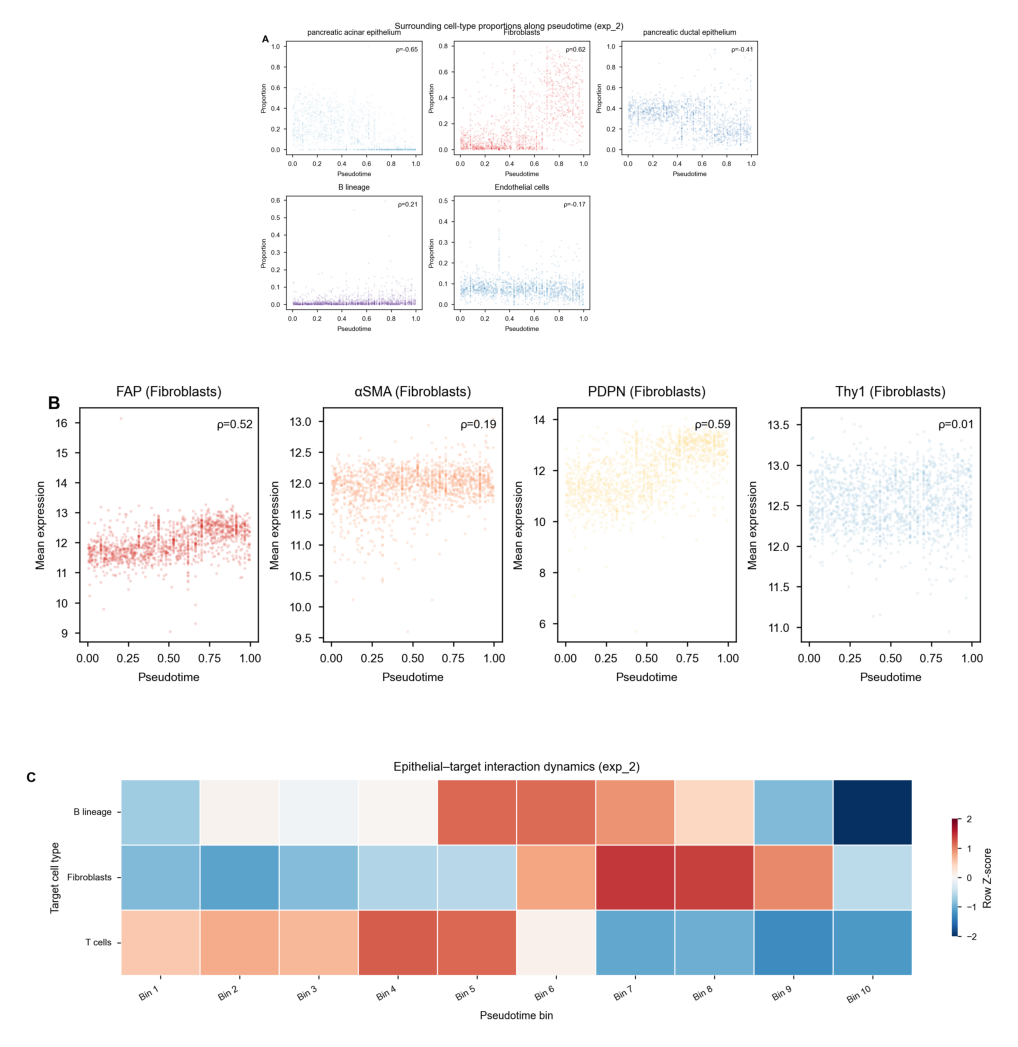

Figure 2 assembled.


In [15]:
# ── Fig 2 composite ───────────────────────────────────────────────────────────
panel_files_f2 = {
    'A': FIG_OUT / 'fig2A_surround_cell_proportion_trends.png',
    'B': FIG_OUT / 'fig2B_fibroblast_activation_trends.png',
    'C': FIG_OUT / 'fig2C_interaction_dynamics_heatmap.png',
}

fig = plt.figure(figsize=(8.5, 9), dpi=150)
gs2 = gridspec.GridSpec(3, 1, figure=fig, hspace=0.1)

for i, (label, pos) in enumerate([('A', 0), ('B', 1), ('C', 2)]):
    pfile = panel_files_f2.get(label)
    if pfile and pfile.exists():
        ax = fig.add_subplot(gs2[pos])
        ax.imshow(mpimg.imread(pfile))
        ax.axis('off')
    
save_fig(fig, 'Figure2_manuscript')
plt.show()
print('Figure 2 assembled.')

---
# Figure 3 — Multi-Sample Pooled Pseudotime and Cross-Modality Validation


In [16]:
# ── Load pooled data ──────────────────────────────────────────────────────────
df_pooled = pd.read_pickle(COMB_DIR / 'pooled_niche_result_df.pkl')
df_pooled_path = pd.read_pickle(COMB_DIR / 'pooled_pathology_with_panin_validation_scores.pkl')

# Merge UMAP/pseudotime/branch from pooled_niche_result into pooled_pathology
merge_keys = ['pancreatic ductal epithelium_mask_component', 'image_id'] \
    if 'image_id' in df_pooled_path.columns else ['pancreatic ductal epithelium_mask_component']

# pooled_niche_result has sample_id, UMAP, branch, pseudotime
df_pooled_merged = df_pooled_path.merge(
    df_pooled[['pancreatic ductal epithelium_mask_component', 'image_id', 'sample_id',
               'disease_group', 'differentiation_label',
               'UMAP1', 'UMAP2', 'major_branch',
               'pooled_pseudotime_q', 'pooled_pseudotime']],
    on=['pancreatic ductal epithelium_mask_component', 'image_id'],
    how='inner',
    suffixes=('', '_r'),
)

print(f'Pooled merged shape: {df_pooled_merged.shape}')
print('Samples:', df_pooled_merged['sample_id'].value_counts().to_dict())

Pooled merged shape: (46574, 641)
Samples: {'35559_1': 21302, '34434_1': 12184, '33694_1': 10186, '40331_1': 2902}


Saved: /Users/shihongwu/SpatioEv/manuscript/figures/fig3A_pooled_umap_diagnostics.pdf/.png


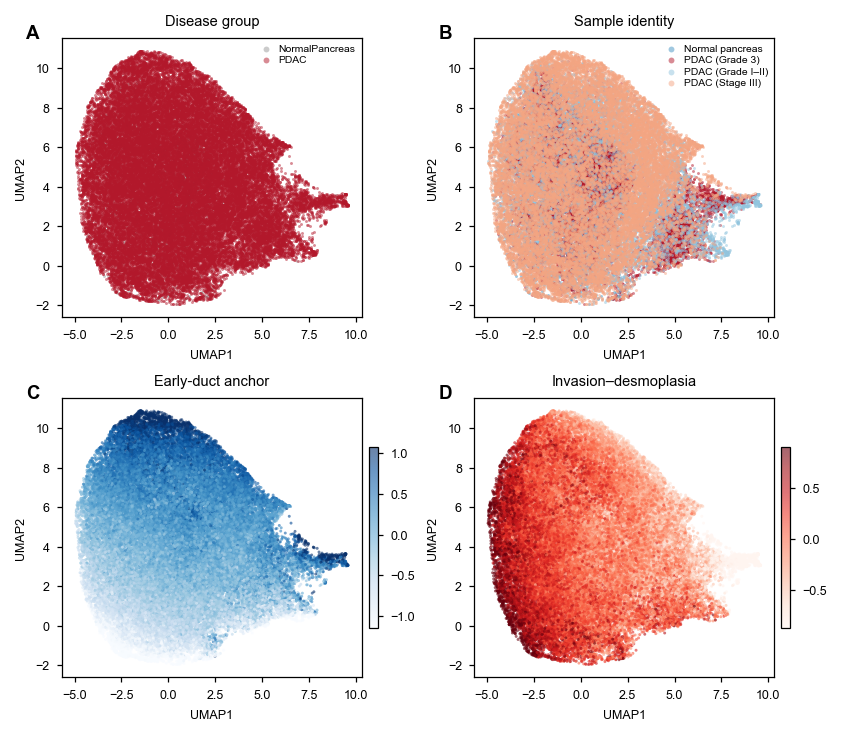

In [17]:
# ── Fig 3A — UMAP diagnostic 2×2 ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(5.5, 4.8), constrained_layout=True)
axes = axes.reshape(-1)

diag_configs = [
    ('disease_group',           'Disease group',     DISEASE_PALETTE,          'categorical'),
    ('sample_id',               'Sample identity',   SAMPLE_PALETTE,           'categorical'),
    ('pdac_early_duct_anchor_score', 'Early-duct anchor', 'Blues',             'continuous'),
    ('pdac_invasion_desmoplasia_score', 'Invasion–desmoplasia', 'Reds',        'continuous'),
]

for ax, (col, title, cmap_or_pal, kind) in zip(axes, diag_configs):
    col_actual = col if col in df_pooled_merged.columns else None
    if col_actual is None:
        ax.set_visible(False); continue

    if kind == 'categorical':
        groups = df_pooled_merged[col_actual].unique()
        for grp in groups:
            mask = df_pooled_merged[col_actual] == grp
            color = cmap_or_pal.get(grp, '#999999') if isinstance(cmap_or_pal, dict) else '#999'
            label = SAMPLE_LABELS.get(grp, grp) if col_actual == 'sample_id' else grp
            ax.scatter(df_pooled_merged.loc[mask, 'UMAP1'],
                       df_pooled_merged.loc[mask, 'UMAP2'],
                       c=color, s=2, linewidths=0, alpha=0.5,
                       rasterized=True, label=label)
        ax.legend(markerscale=2, frameon=False, fontsize=5,
                  handlelength=0.8, labelspacing=0.2, borderpad=0.1)
    else:
        v = pd.to_numeric(df_pooled_merged[col_actual], errors='coerce')
        vmin, vmax = v.quantile(0.02), v.quantile(0.98)
        sc = ax.scatter(df_pooled_merged['UMAP1'], df_pooled_merged['UMAP2'],
                        c=v.clip(vmin, vmax), cmap=cmap_or_pal,
                        s=2, linewidths=0, alpha=0.6,
                        vmin=vmin, vmax=vmax, rasterized=True)
        plt.colorbar(sc, ax=ax, shrink=0.65, pad=0.02)

    ax.set_title(title, fontsize=7)
    ax.set_xlabel('UMAP1', fontsize=6); ax.set_ylabel('UMAP2', fontsize=6)

for i, ax in enumerate(axes):
    ax.text(-0.12, 1.05, 'ABCD'[i], transform=ax.transAxes,
            fontsize=9, fontweight='bold', va='top')

save_fig(fig, 'fig3A_pooled_umap_diagnostics')
plt.show()

Saved: /Users/shihongwu/SpatioEv/manuscript/figures/fig3B_pooled_umap_branches.pdf/.png


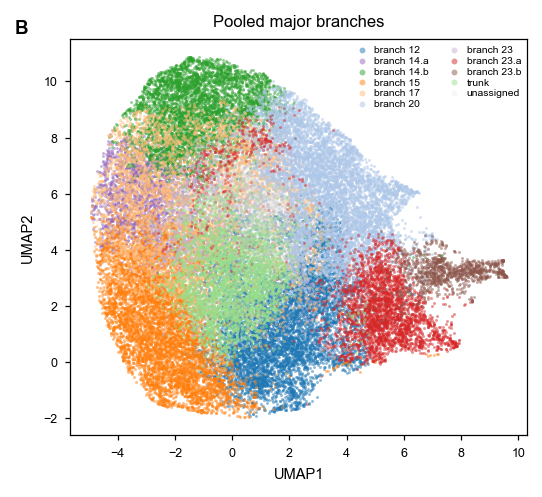

In [18]:
# ── Fig 3B — Major branches on pooled UMAP ────────────────────────────────────
# Focus on the top branches by population size
branch_counts = df_pooled_merged['major_branch'].value_counts()
top_branches = branch_counts[branch_counts > len(df_pooled_merged) * 0.02].index.tolist()
# Map branch names to biological labels (auto from z-enrichment if available)

# Use tab20 for branches
branch_pal_pooled = dict(zip(top_branches, sns.color_palette('tab20', len(top_branches))))
branch_pal_pooled['unassigned'] = '#cccccc'

fig, ax = plt.subplots(figsize=(3.5, 3.2), constrained_layout=True)
for branch, grp in df_pooled_merged.groupby('major_branch'):
    if branch not in branch_pal_pooled:
        continue
    ax.scatter(grp['UMAP1'], grp['UMAP2'],
               c=[branch_pal_pooled[branch]], s=2, linewidths=0,
               alpha=0.5 if branch != 'unassigned' else 0.15,
               rasterized=True, label=branch)

ax.legend(markerscale=2, frameon=False, fontsize=5,
          handlelength=0.8, labelspacing=0.15, borderpad=0.1,
          ncol=2)
ax.set_xlabel('UMAP1'); ax.set_ylabel('UMAP2')
ax.set_title('Pooled major branches')
ax.text(-0.12, 1.05, 'B', transform=ax.transAxes,
        fontsize=9, fontweight='bold', va='top')

save_fig(fig, 'fig3B_pooled_umap_branches')
plt.show()

Saved: /Users/shihongwu/SpatioEv/manuscript/figures/fig3C_pseudotime_boxplot_by_sample.pdf/.png


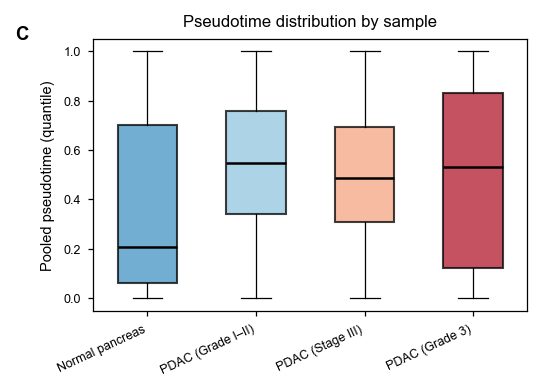

In [19]:
# ── Fig 3C — Per-sample pseudotime distribution boxplot ──────────────────────
# Ordered: normal → PDAC early → PDAC intermediate → PDAC invasive
SAMPLE_ORDER = ['40331_1', '33694_1', '35559_1', '34434_1']
sample_order = [s for s in SAMPLE_ORDER if s in df_pooled_merged['sample_id'].unique()]

fig, ax = plt.subplots(figsize=(3.5, 2.5), constrained_layout=True)
plot_data = [
    df_pooled_merged.loc[
        df_pooled_merged['sample_id'] == s, 'pooled_pseudotime_q'
    ].dropna().values
    for s in sample_order
]
bp = ax.boxplot(
    plot_data,
    patch_artist=True,
    notch=False,
    medianprops=dict(color='black', linewidth=1.2),
    whiskerprops=dict(linewidth=0.6),
    capprops=dict(linewidth=0.6),
    flierprops=dict(marker='.', markersize=1, alpha=0.3, linewidth=0),
    widths=0.55,
)
for patch, sample_id in zip(bp['boxes'], sample_order):
    patch.set_facecolor(SAMPLE_PALETTE.get(sample_id, '#999999'))
    patch.set_alpha(0.75)

ax.set_xticks(range(1, len(sample_order) + 1))
ax.set_xticklabels([SAMPLE_LABELS.get(s, s) for s in sample_order],
                    rotation=25, ha='right', fontsize=6)
ax.set_ylabel('Pooled pseudotime (quantile)')
ax.set_title('Pseudotime distribution by sample')
ax.text(-0.18, 1.05, 'C', transform=ax.transAxes,
        fontsize=9, fontweight='bold', va='top')

save_fig(fig, 'fig3C_pseudotime_boxplot_by_sample')
plt.show()

Saved: /Users/shihongwu/SpatioEv/manuscript/figures/fig3D_pooled_branch_module_trends.pdf/.png


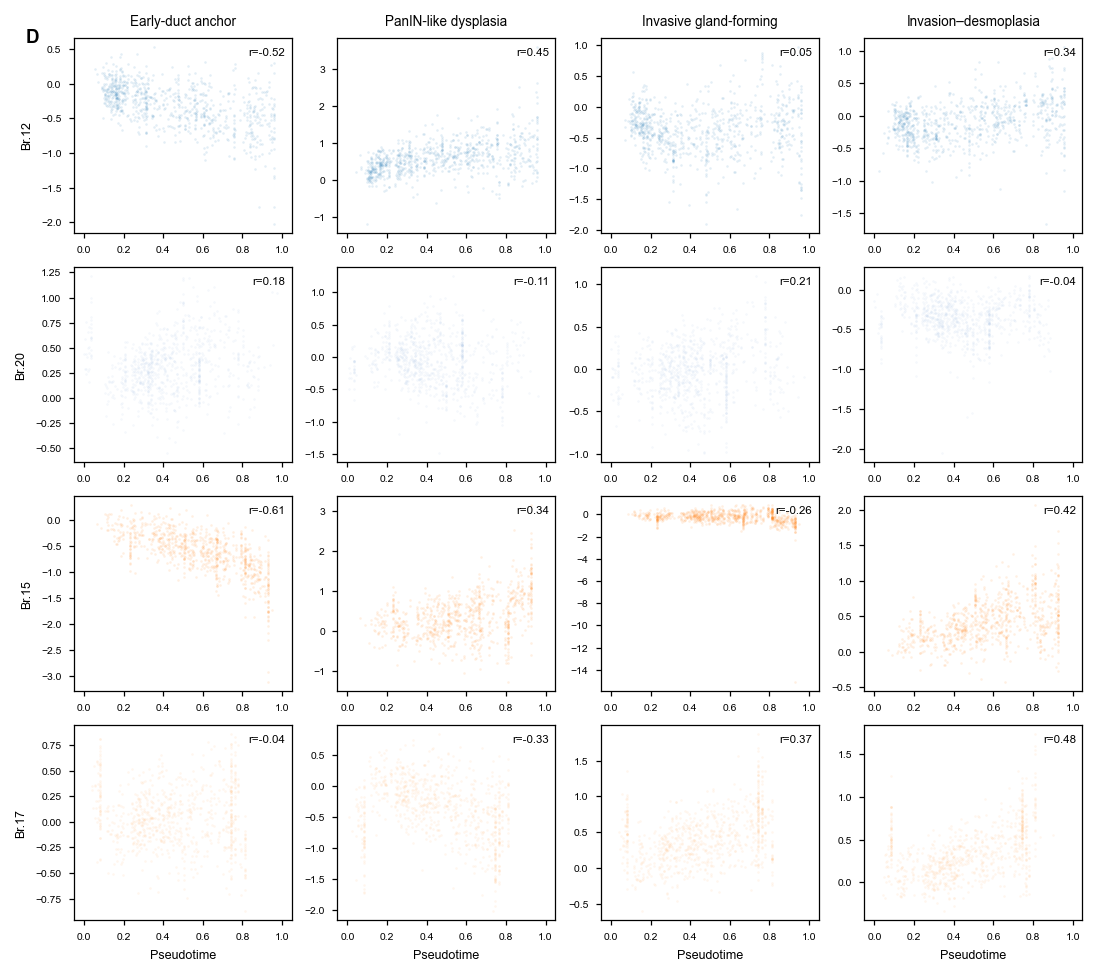

In [20]:
# ── Fig 3D — Branch-stratified module trends (pooled) ─────────────────────────
pooled_mod_cols = [
    'pdac_early_duct_anchor_score',
    'pdac_panin_like_dysplasia_score',
    'pdac_invasive_gland_forming_score',
    'pdac_invasion_desmoplasia_score',
]
pooled_mod_cols = [c for c in pooled_mod_cols if c in df_pooled_merged.columns]

# Select top 4 branches by n
top4 = [b for b in branch_counts.index if b != 'unassigned'][:4]

fig, axes = plt.subplots(len(top4), len(pooled_mod_cols),
                          figsize=(len(pooled_mod_cols) * 1.8, len(top4) * 1.6),
                          constrained_layout=True)

for r, branch in enumerate(top4):
    br_data = df_pooled_merged[df_pooled_merged['major_branch'] == branch]
    color = branch_pal_pooled.get(branch, '#555555')

    for c, mod_col in enumerate(pooled_mod_cols):
        ax = axes[r, c] if len(top4) > 1 else axes[c]
        vals = pd.to_numeric(br_data[mod_col], errors='coerce')
        pt   = pd.to_numeric(br_data['pooled_pseudotime_q'], errors='coerce')
        mask = ~(np.isnan(vals) | np.isnan(pt))

        if mask.sum() < 20:
            ax.set_visible(False); continue

        idx = np.random.choice(np.where(mask)[0], size=min(800, mask.sum()), replace=False)
        ax.scatter(pt.values[idx], vals.values[idx],
                   c=color, s=1.5, alpha=0.12, linewidths=0, rasterized=True)
        try:
            lx, ly = lowess_smooth(pt.values[mask], vals.values[mask], frac=0.3)
            ax.plot(lx, ly, color=color, linewidth=1.5)
        except Exception:
            pass

        r_val, _ = stats.pearsonr(pt.values[mask], vals.values[mask])
        ax.text(0.97, 0.95, f'r={r_val:.2f}', transform=ax.transAxes,
                ha='right', va='top', fontsize=5.5)

        if r == 0:
            ax.set_title(MODULE_LABELS.get(mod_col, mod_col), fontsize=6.5)
        if c == 0:
            ax.set_ylabel(branch.replace('branch ', 'Br.'), fontsize=6)
        if r == len(top4) - 1:
            ax.set_xlabel('Pseudotime', fontsize=6)

        ax.tick_params(labelsize=5)
        ax.set_xlim(-0.05, 1.05)

axes[0, 0].text(-0.22, 1.05, 'D', transform=axes[0, 0].transAxes,
                fontsize=9, fontweight='bold', va='top')

save_fig(fig, 'fig3D_pooled_branch_module_trends')
plt.show()

Saved: /Users/shihongwu/SpatioEv/manuscript/figures/fig3F_spatial_pseudotime_all_samples.pdf/.png


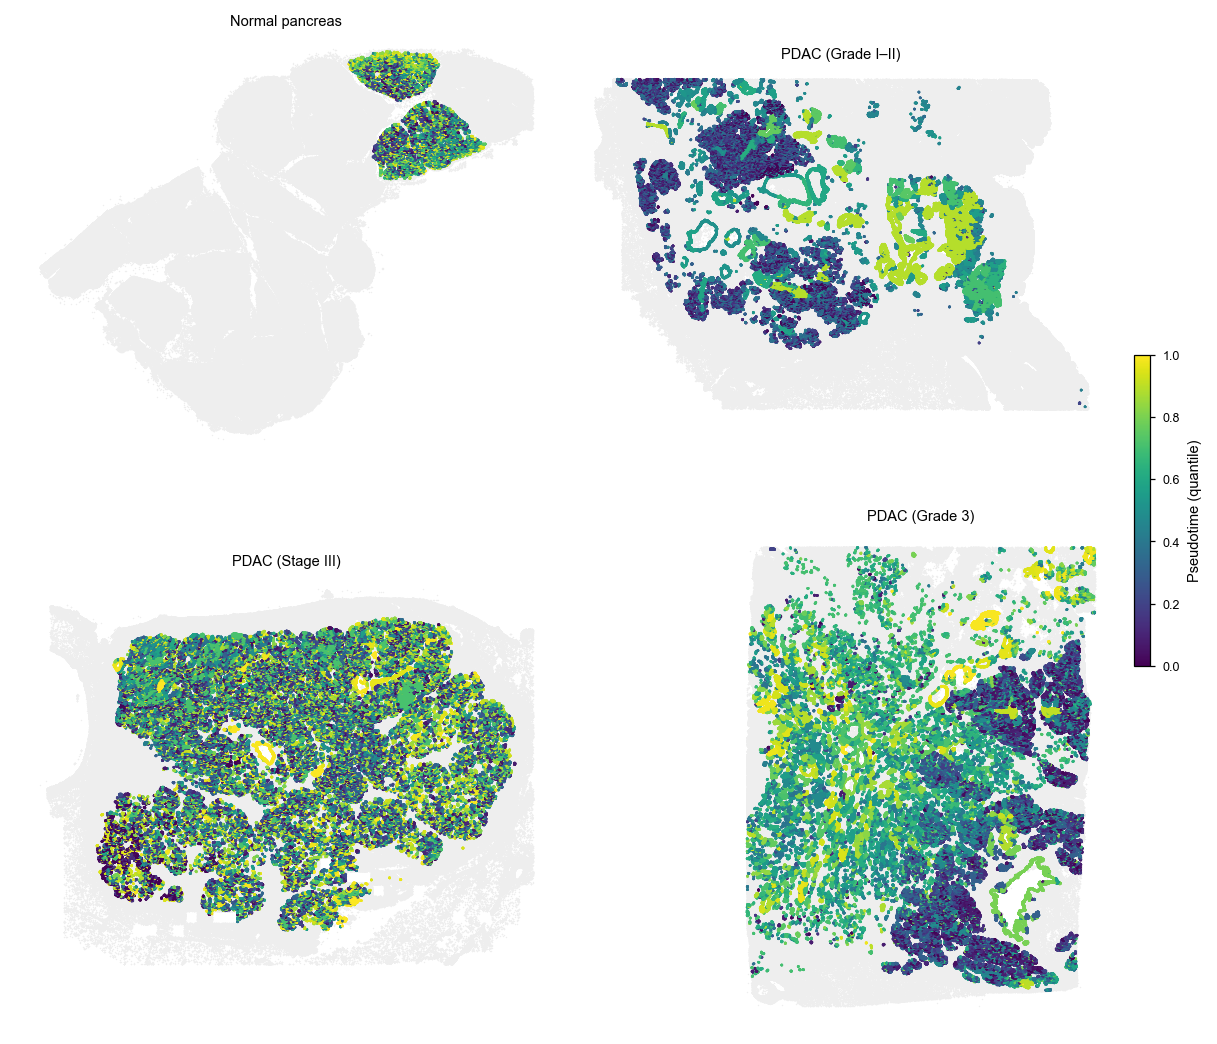

In [21]:
# ── Fig 3F — Spatial maps of pseudotime in all 4 samples ──────────────────────
SPATIAL_SAMPLES = ['40331_1', '33694_1', '35559_1', '34434_1']
spatial_version = 'auto_branch_n36_v5_contextual'

fig, big_axes = plt.subplots(2, 2, figsize=(8.0, 7.0), constrained_layout=True)
big_axes = big_axes.reshape(-1)

for ax_outer, sample_id in zip(big_axes, SPATIAL_SAMPLES):
    pkl_path = COMB_DIR / f'spatial_cells_{spatial_version}_{sample_id}.pkl'
    if not pkl_path.exists():
        ax_outer.text(0.5, 0.5, f'No data\n{sample_id}', ha='center', va='center',
                      transform=ax_outer.transAxes, fontsize=7)
        ax_outer.axis('off')
        continue

    df_s = pd.read_pickle(pkl_path)
    df_duct_s = df_s[df_s['has_pooled_niche'] == True]
    df_bg_s   = df_s[df_s['has_pooled_niche'] == False]

    # FIX: spatial cells use pooled_pseudotime (0-22); quantile-normalise inline.
    pt_raw_col_s = 'pooled_pseudotime' if 'pooled_pseudotime' in df_duct_s.columns else 'simple_pseudotime'
    pt_vals_s = pd.to_numeric(df_duct_s[pt_raw_col_s], errors='coerce').rank(pct=True).clip(0, 1)

    ax_outer.scatter(df_bg_s['x'], df_bg_s['y'],
                     c='#eeeeee', s=0.5, linewidths=0, rasterized=True, zorder=1)
    sc = ax_outer.scatter(df_duct_s['x'], df_duct_s['y'],
                          c=pt_vals_s,
                          cmap='viridis', s=1.5, linewidths=0,
                          vmin=0, vmax=1, rasterized=True, zorder=2)

    ax_outer.set_aspect('equal')
    ax_outer.axis('off')
    ax_outer.set_title(SAMPLE_LABELS.get(sample_id, sample_id), fontsize=7, pad=2)

# Shared colorbar
sm = ScalarMappable(cmap='viridis', norm=Normalize(0, 1))
sm.set_array([])
cbar = fig.colorbar(sm, ax=big_axes, shrink=0.3, label='Pseudotime (quantile)', pad=0.02)
cbar.ax.tick_params(labelsize=6)

save_fig(fig, 'fig3F_spatial_pseudotime_all_samples')
plt.show()

In [22]:
# ── Fig 3G/H — Xenium cross-modality panels (copy pre-generated PDFs) ─────────
# These panels were generated by notebook 07_xenium_04_transcriptional_trends.ipynb
# We import and display them here; they are already at publication quality.

import shutil

xenium_panels = {
    'fig3G_xenium_crossmodality_concordance':   'fig_crossmodality_concordance.pdf',
    'fig3H_xenium_pseudotime_bin_heatmap':      'fig_pseudotime_bin_heatmap.pdf',
    'fig3H_xenium_gene_trends_common':          'fig_gene_trends_common.pdf',
    'fig3H_xenium_surround_trends':             'fig_surround_trends.pdf',
}

for dest_name, src_name in xenium_panels.items():
    src = XENIUM_FIG / src_name
    dst = FIG_OUT / f'{dest_name}.pdf'
    if src.exists():
        shutil.copy(src, dst)
        print(f'Copied: {dst.name}')
    else:
        print(f'Missing: {src}')

# Display concordance figure
from IPython.display import display, Image
concordance_png = FIG_OUT / 'fig3G_xenium_crossmodality_concordance.pdf'
print('\nXenium panels copied to', FIG_OUT)

Copied: fig3G_xenium_crossmodality_concordance.pdf
Copied: fig3H_xenium_pseudotime_bin_heatmap.pdf
Copied: fig3H_xenium_gene_trends_common.pdf
Copied: fig3H_xenium_surround_trends.pdf

Xenium panels copied to /Users/shihongwu/SpatioEv/manuscript/figures


Saved: /Users/shihongwu/SpatioEv/manuscript/figures/Figure3_manuscript_AtoF.pdf/.png


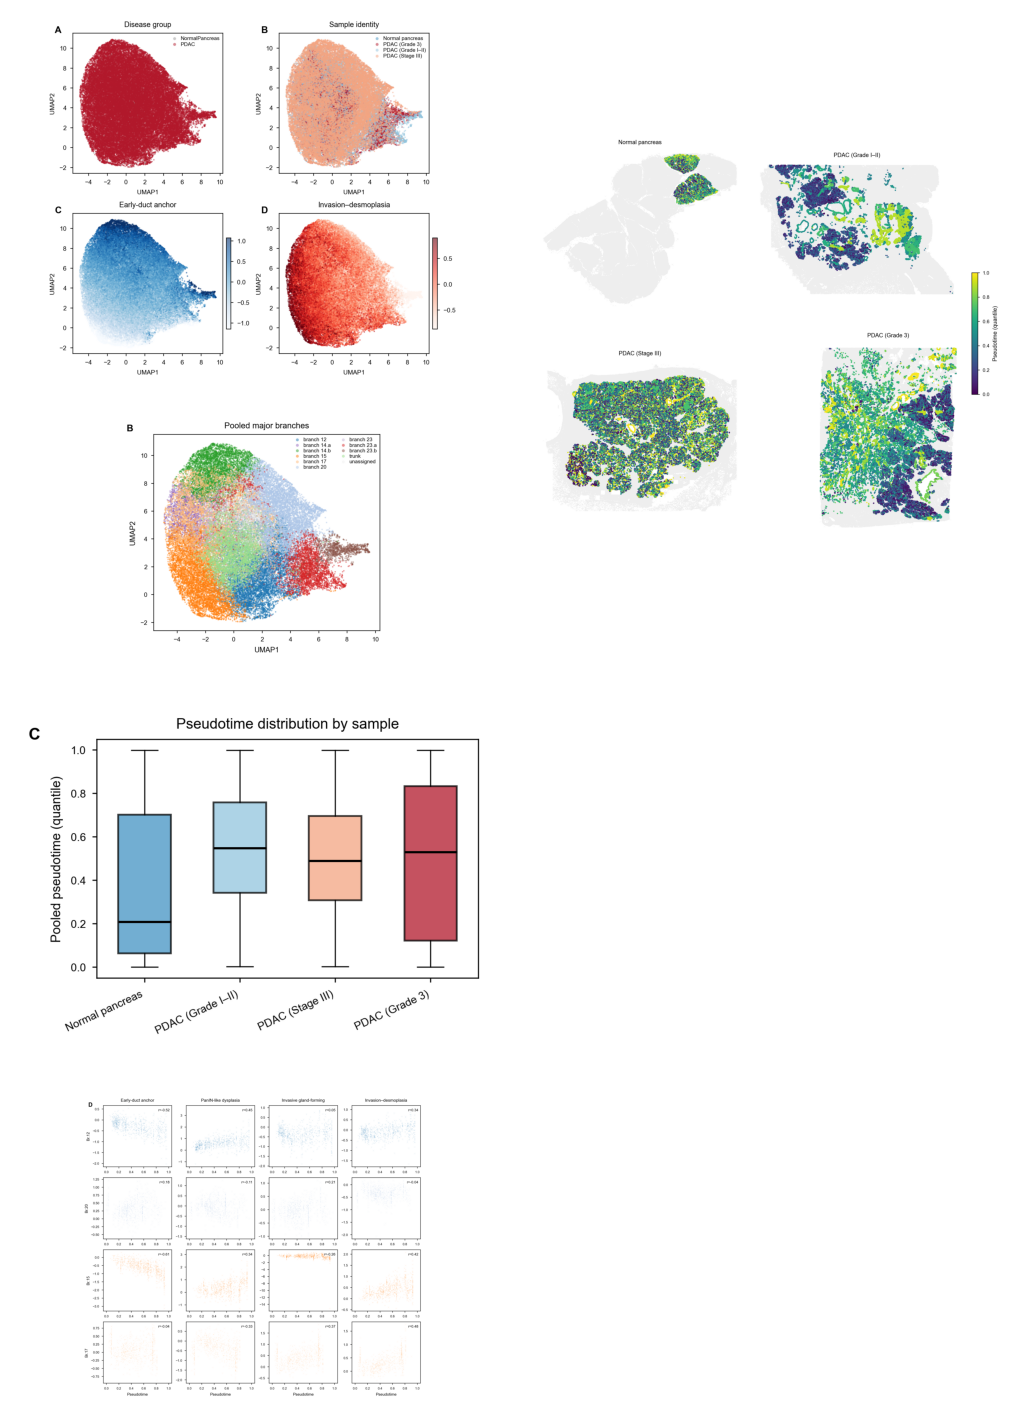

Figure 3 (panels A-F) assembled.


In [23]:
# ── Fig 3 composite ───────────────────────────────────────────────────────────
# Left column: 3A (UMAP 2x2), 3B (branches), 3C (boxplot), 3D (trends grid)
# Right column: 3F (spatial maps), 3G (concordance), 3H (heatmap)

fig = plt.figure(figsize=(8.5, 12), dpi=150)
gs3 = gridspec.GridSpec(4, 2, figure=fig, hspace=0.1, wspace=0.08,
                         height_ratios=[1.2, 0.8, 1.2, 1.0])

panel_map = [
    ('fig3A_pooled_umap_diagnostics',  gs3[0, 0]),
    ('fig3B_pooled_umap_branches',     gs3[1, 0]),
    ('fig3C_pseudotime_boxplot_by_sample', gs3[2, 0]),
    ('fig3D_pooled_branch_module_trends',  gs3[3, 0]),
    ('fig3F_spatial_pseudotime_all_samples', gs3[0:2, 1]),
]

for name, pos in panel_map:
    png = FIG_OUT / f'{name}.png'
    if png.exists():
        ax = fig.add_subplot(pos)
        ax.imshow(mpimg.imread(png))
        ax.axis('off')

save_fig(fig, 'Figure3_manuscript_AtoF')
plt.show()
print('Figure 3 (panels A-F) assembled.')

---
## Summary of generated files

All panels and composites are saved to `manuscript/figures/` as both PDF (vector, for Illustrator) and PNG (300 dpi, for quick viewing).

| File | Content |
|------|---------|
| `fig1D_pca_scree_and_module_pca` | PCA scree + 2D PCA coloured by modules |
| `fig1E_umap_branch_pseudotime` | UMAP with branches + pseudotime |
| `fig1F_spatial_pseudotime_exp2` | Spatial map of pseudotime per FOV (exp_2) |
| `fig1G_module_lowess_trends_exp2` | LOWESS module trends |
| `fig1H_branch_module_heatmap_exp2` | Branch × module z-enrichment heatmap |
| `fig1I_panin_validation_exp2` | PanIN validation scores along pseudotime |
| `Figure1_manuscript_DtoI` | Composite Figure 1 |
| `fig2A_surround_cell_proportion_trends` | Surrounding cell proportions |
| `fig2B_fibroblast_activation_trends` | CAF activation markers |
| `fig2C_interaction_dynamics_heatmap` | Interaction dynamics heatmap |
| `Figure2_manuscript` | Composite Figure 2 |
| `fig3A_pooled_umap_diagnostics` | Pooled UMAP 2×2 |
| `fig3B_pooled_umap_branches` | Major branches on UMAP |
| `fig3C_pseudotime_boxplot_by_sample` | Pseudotime boxplot by sample |
| `fig3D_pooled_branch_module_trends` | Branch-stratified module trends |
| `fig3F_spatial_pseudotime_all_samples` | Spatial maps of all 4 samples |
| `fig3G_xenium_crossmodality_concordance` | Cross-modality concordance |
| `fig3H_xenium_pseudotime_bin_heatmap` | Xenium pseudotime bin heatmap |
| `Figure3_manuscript_AtoF` | Composite Figure 3 |
